# Modelo 4 — Lei de Okun: Elasticidade do Produto (Fase 4)
## TCC — Análise da Lei de Okun para o Brasil (UFRPE)

Este notebook estima a **relação inversa da Lei de Okun**, utilizando o **logaritmo do PIB como variável dependente** e a taxa de desemprego como variável explicativa, controlando para uma tendência de tempo determinística e quebras metodológicas nas pesquisas de emprego.

### Equação Estimada

$$\ln\_pib_t = \beta_0 + \beta_1 \cdot t + \beta_2 \cdot u_t + \gamma_1 D_{PMENova} + \gamma_2 D_{PNADc} + \varepsilon_t$$

| Parâmetro | Significado Econômico |
|-----------|----------------------|
| **β₁** | Taxa de crescimento trimestral do PIB potencial (tendência determinística) |
| **β₂** | **Elasticidade de Okun**: variação % no PIB por 1 p.p. na taxa de desemprego — espera-se β₂ < 0 |
| **γ₁, γ₂** | Correção dos shifts metodológicos das pesquisas PME Nova (2002) e PNADc (2012) |

### Produto Potencial e Hiato Implícito

Após a estimação, o **Produto Potencial** (Y\*) é derivado fixando u_t na NAIRU estimada pelo Modelo 2 (Hamilton).
O **hiato implícito** é: $\text{hiato\_elast}_t = (\ln\_pib_t - \ln Y^*_t) \times 100$

### Teste de Cointegração (Engle-Granger)

Como `ln_pib` e `u_t` são variáveis I(1), o procedimento de Engle-Granger (2 etapas) é aplicado sobre os resíduos da regressão para verificar a existência de uma relação de longo prazo válida.

In [1]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# ── PALETA E PERÍODOS DE METODOLOGIA ──────────────────────────────────────────
COR_PRINCIPAL = '#2563EB'
COR_FITTED    = '#DC2626'
COR_POTENCIAL = '#059669'
COR_HIATO     = '#D97706'
COR_ZERO      = '#6B7280'
ALPHA_SHADE   = 0.08

PERIODOS_MET = [
    ('1994-03-31', '2002-03-31', '#FBBF24', 'PME Antiga'),
    ('2002-03-31', '2012-03-31', '#86EFAC', 'PME Nova'),
    ('2012-03-31', '2025-01-01', '#93C5FD', 'PNADc'),
]

def sombrear_periodos(ax):
    for ini, fim, cor, label in PERIODOS_MET:
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fim),
                   alpha=ALPHA_SHADE, color=cor, label=label)

FIG_DIR = '../figuras/fase4_modelo4'
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Diretório de figuras: {FIG_DIR}')

Diretório de figuras: ../figuras/fase4_modelo4


In [2]:
# ── CARREGAMENTO DOS DADOS ────────────────────────────────────────────────────
pib_df        = pd.read_pickle('../dados/pib_tratado.pkl')
desemprego_df = pd.read_pickle('../dados/desemprego_tratado.pkl')

df = pib_df.join(desemprego_df[['desemprego']], how='inner')
df = df.rename(columns={'desemprego': 'u_t'})
df = df.loc['1996-01-01':'2024-12-31'].copy()
df = df.dropna(subset=['ln_pib', 'u_t'])

# ── STEP DUMMIES (idênticas ao Modelo 2) ─────────────────────────────────────
df['d_PMENova'] = (df.index >= '2002-03-31').astype(float)
df['d_PNADc']   = (df.index >= '2012-03-31').astype(float)

# ── TENDÊNCIA DE TEMPO DETERMINÍSTICA ────────────────────────────────────────
# t = 1, 2, ..., N  — cada unidade = 1 trimestre
df['t'] = np.arange(1, len(df) + 1, dtype=float)

print(f"Dataset: {len(df)} observações  |  {df.index[0].date()} → {df.index[-1].date()}")
print(df[['u_t', 'ln_pib', 't']].describe().round(3))

Dataset: 116 observações  |  1996-03-31 → 2024-12-31
           u_t   ln_pib       t
count  116.000  116.000  116.00
mean     9.154   12.450   58.50
std      2.461    0.199   33.63
min      4.843   12.075    1.00
25%      7.200   12.243   29.75
50%      8.503   12.538   58.50
75%     11.425   12.616   87.25
max     14.633   12.730  116.00


fig_17 salva


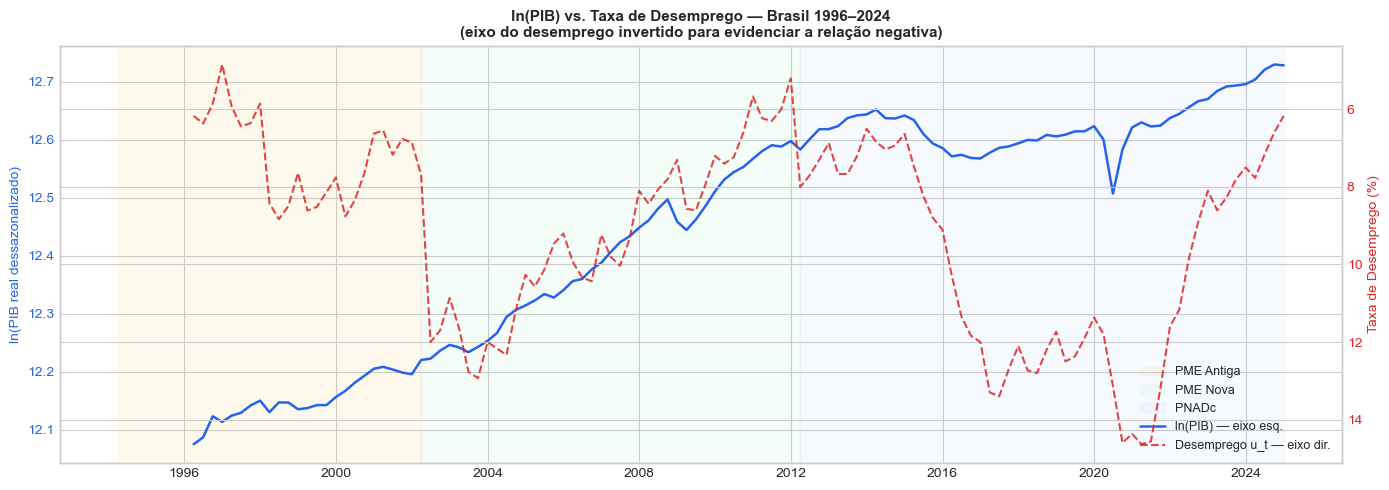

In [3]:
# ── GRÁFICO EXPLORATÓRIO: ln_pib e u_t no mesmo eixo temporal ─────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))
sombrear_periodos(ax1)

ax1.plot(df.index, df['ln_pib'], color=COR_PRINCIPAL, linewidth=1.8,
         label='ln(PIB) — eixo esq.')
ax1.set_ylabel('ln(PIB real dessazonalizado)', fontsize=10, color=COR_PRINCIPAL)
ax1.tick_params(axis='y', labelcolor=COR_PRINCIPAL)

ax2 = ax1.twinx()
ax2.plot(df.index, df['u_t'], color=COR_FITTED, linewidth=1.5, linestyle='--',
         alpha=0.85, label='Desemprego u_t — eixo dir.')
ax2.set_ylabel('Taxa de Desemprego (%)', fontsize=10, color=COR_FITTED)
ax2.tick_params(axis='y', labelcolor=COR_FITTED)
ax2.invert_yaxis()  # inverter para facilitar a visualização da relação negativa

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower right')

ax1.set_title('ln(PIB) vs. Taxa de Desemprego — Brasil 1996–2024\n'
              '(eixo do desemprego invertido para evidenciar a relação negativa)',
              fontsize=11, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(4))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_17_exploratoria_pib_desemprego.png', dpi=150, bbox_inches='tight')
print('fig_17 salva')
plt.show()

In [4]:
# ── TESTES DE RAIZ UNITÁRIA (ADF) — JUSTIFICATIVA DO TESTE DE COINTEGRAÇÃO ───
# H₀: série tem raiz unitária (I(1))  /  H₁: série é estacionária (I(0))

def teste_adf(serie, nome, regression='ct', nlags=4):
    """ADF com constante e tendência (para séries com trend) ou só constante."""
    result = adfuller(serie.dropna(), regression=regression, maxlag=nlags, autolag='AIC')
    stat, pval, lags_used = result[0], result[1], result[2]
    crit = result[4]
    conclusao = 'I(0) — Estacionária ✓' if pval < 0.05 else 'I(1) — Raiz Unitária ✗'
    print(f"{'─'*55}")
    print(f"ADF — {nome}")
    print(f"  Estatística: {stat:.4f}  |  p-valor: {pval:.4f}  |  Lags: {lags_used}")
    print(f"  Valores críticos: 1%={crit['1%']:.3f}  5%={crit['5%']:.3f}  10%={crit['10%']:.3f}")
    print(f"  Conclusão: {conclusao}")
    return pval

print('=== TESTES ADF — NÍVEL ===')
p_pib   = teste_adf(df['ln_pib'], 'ln_pib (nível, c+t)', regression='ct')
p_ut    = teste_adf(df['u_t'],    'u_t    (nível, c)',   regression='c')

print('\n=== TESTES ADF — PRIMEIRA DIFERENÇA ===')
p_dpib  = teste_adf(df['ln_pib'].diff(), 'Δln_pib (1ª dif.)', regression='c')
p_dut   = teste_adf(df['u_t'].diff(),    'Δu_t    (1ª dif.)', regression='c')

print('\n→ Ambas as variáveis são I(1): o teste de cointegração é necessário.')

=== TESTES ADF — NÍVEL ===
───────────────────────────────────────────────────────
ADF — ln_pib (nível, c+t)
  Estatística: -1.3983  |  p-valor: 0.8614  |  Lags: 0
  Valores críticos: 1%=-4.040  5%=-3.449  10%=-3.150
  Conclusão: I(1) — Raiz Unitária ✗
───────────────────────────────────────────────────────
ADF — u_t    (nível, c)
  Estatística: -3.4524  |  p-valor: 0.0093  |  Lags: 4
  Valores críticos: 1%=-3.491  5%=-2.888  10%=-2.581
  Conclusão: I(0) — Estacionária ✓

=== TESTES ADF — PRIMEIRA DIFERENÇA ===
───────────────────────────────────────────────────────
ADF — Δln_pib (1ª dif.)
  Estatística: -8.6429  |  p-valor: 0.0000  |  Lags: 1
  Valores críticos: 1%=-3.490  5%=-2.887  10%=-2.581
  Conclusão: I(0) — Estacionária ✓
───────────────────────────────────────────────────────
ADF — Δu_t    (1ª dif.)
  Estatística: -4.0205  |  p-valor: 0.0013  |  Lags: 4
  Valores críticos: 1%=-3.491  5%=-2.888  10%=-2.581
  Conclusão: I(0) — Estacionária ✓

→ Ambas as variáveis são I(1): o tes

In [5]:
# ── ESTIMAÇÃO OLS COM CORREÇÃO HAC (Newey-West, maxlags=4) ───────────────────
Y = df['ln_pib']
X = sm.add_constant(df[['t', 'u_t', 'd_PMENova', 'd_PNADc']])

modelo = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(modelo.summary())

# Extrair coeficientes
beta0  = modelo.params['const']
beta1  = modelo.params['t']          # tendência
beta2  = modelo.params['u_t']        # elasticidade
gamma1 = modelo.params['d_PMENova']
gamma2 = modelo.params['d_PNADc']

print(f"\n{'='*55}")
print(f"RESULTADO PRINCIPAL")
print(f"{'='*55}")
print(f"β₁ (tendência):    {beta1:.6f}  →  {beta1*100:.4f}% por trimestre  ({beta1*400:.3f}% ao ano)")
print(f"β₂ (elasticidade): {beta2:.4f}   →  {beta2:.4f}% no PIB por +1 p.p. em u_t")
print(f"R² Ajustado:       {modelo.rsquared_adj:.4f}")
print(f"AIC:               {modelo.aic:.2f}")

                            OLS Regression Results                            
Dep. Variable:                 ln_pib   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     382.6
Date:                Sun, 17 May 2026   Prob (F-statistic):           6.18e-64
Time:                        10:25:20   Log-Likelihood:                 222.26
No. Observations:                 116   AIC:                            -434.5
Df Residuals:                     111   BIC:                            -420.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.2424      0.022    558.921      0.0

In [6]:
# ── FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF) — MULTICOLINEARIDADE ────────────────
# VIF > 10: problema sério  |  5 < VIF ≤ 10: atenção  |  VIF ≤ 5: aceitável

X_matrix = sm.add_constant(df[['t', 'u_t', 'd_PMENova', 'd_PNADc']])
vif_df = pd.DataFrame({
    'Variável': X_matrix.columns,
    'VIF':      [variance_inflation_factor(X_matrix.values, i)
                 for i in range(X_matrix.shape[1])]
})
vif_df['Avaliação'] = vif_df['VIF'].apply(
    lambda v: '✓ Ok' if v < 5 else ('⚠ Atenção' if v < 10 else '✗ Crítico')
)
print('=== FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF) ===')
print(vif_df.to_string(index=False))
print()
print('Nota: VIF elevado para `t` e `u_t` é esperado — ambas as variáveis têm componente de')
print('tendência. Na regressão de cointegração isso é inerente à estrutura I(1).')

=== FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF) ===
 Variável       VIF Avaliação
    const 17.188084 ✗ Crítico
        t  7.217320 ⚠ Atenção
      u_t  1.239063      ✓ Ok
d_PMENova  2.562160      ✓ Ok
  d_PNADc  4.733164      ✓ Ok

Nota: VIF elevado para `t` e `u_t` é esperado — ambas as variáveis têm componente de
tendência. Na regressão de cointegração isso é inerente à estrutura I(1).


In [7]:
# ── TESTES DE DIAGNÓSTICO DOS RESÍDUOS ───────────────────────────────────────
residuos = modelo.resid

jb_stat, jb_p, jb_sk, jb_ku = jarque_bera(residuos)
bg_stat, bg_p, _, _          = acorr_breusch_godfrey(modelo, nlags=4)
wh_stat, wh_p, _, _          = het_white(residuos, modelo.model.exog)

print('=== DIAGNÓSTICO DOS RESÍDUOS ===')
print(f"Jarque-Bera       — stat={jb_stat:.3f}  p={jb_p:.4f}  {'✓ Normal' if jb_p>0.05 else '✗ Não-Normal'}")
print(f"  Skewness={jb_sk:.3f}  Kurtosis={jb_ku:.3f}")
print(f"Breusch-Godfrey   — stat={bg_stat:.3f}  p={bg_p:.4f}  (corrigido por HAC)")
print(f"White             — stat={wh_stat:.3f}  p={wh_p:.4f}  {'✓ Homoc.' if wh_p>0.05 else '✗ Heteroc. (HAC corrige)'}")

=== DIAGNÓSTICO DOS RESÍDUOS ===
Jarque-Bera       — stat=10.775  p=0.0046  ✗ Não-Normal
  Skewness=-0.717  Kurtosis=3.415
Breusch-Godfrey   — stat=73.351  p=0.0000  (corrigido por HAC)
White             — stat=74.501  p=0.0000  ✗ Heteroc. (HAC corrige)


In [8]:
# ── TESTE DE COINTEGRAÇÃO — ENGLE-GRANGER (2 ETAPAS) ─────────────────────────
# Etapa 1: regressão OLS (já feita acima)
# Etapa 2: ADF sobre os resíduos — H₀: resíduos I(1) (sem cointegração)
#          regression='n' (sem constante) porque os resíduos OLS têm média zero por construção

adf_res = adfuller(residuos, regression='n', maxlag=4, autolag='AIC')
stat_eg, pval_eg, lags_eg = adf_res[0], adf_res[1], adf_res[2]
crit_eg = adf_res[4]

print('=== TESTE DE COINTEGRAÇÃO — ENGLE-GRANGER ===')
print(f'ADF sobre resíduos da regressão (sem constante):')
print(f'  Estatística ADF: {stat_eg:.4f}')
print(f'  p-valor:         {pval_eg:.4f}')
print(f'  Lags utilizados: {lags_eg}')
print(f'  Valores críticos: 1%={crit_eg["1%"]:.3f}  5%={crit_eg["5%"]:.3f}  10%={crit_eg["10%"]:.3f}')
print()
if pval_eg < 0.05:
    print('  ✓ REJEITA H₀: resíduos são estacionários → COINTEGRAÇÃO CONFIRMADA')
    print('  A relação de longo prazo entre ln_pib e u_t é válida (não-espúria).')
else:
    print('  ✗ NÃO REJEITA H₀: resíduos podem ser I(1) → relação potencialmente espúria')
    print('  Atenção: interpretar os coeficientes com cautela.')
print()
print('Nota: os valores críticos do ADF padrão são conservadores para a regressão')
print('de cointegração (MacKinnon 1991/2010 fornece valores mais precisos para k>1).')

=== TESTE DE COINTEGRAÇÃO — ENGLE-GRANGER ===
ADF sobre resíduos da regressão (sem constante):
  Estatística ADF: -3.5574
  p-valor:         0.0004
  Lags utilizados: 0
  Valores críticos: 1%=-2.585  5%=-1.944  10%=-1.615

  ✓ REJEITA H₀: resíduos são estacionários → COINTEGRAÇÃO CONFIRMADA
  A relação de longo prazo entre ln_pib e u_t é válida (não-espúria).

Nota: os valores críticos do ADF padrão são conservadores para a regressão
de cointegração (MacKinnon 1991/2010 fornece valores mais precisos para k>1).


fig_18 salva


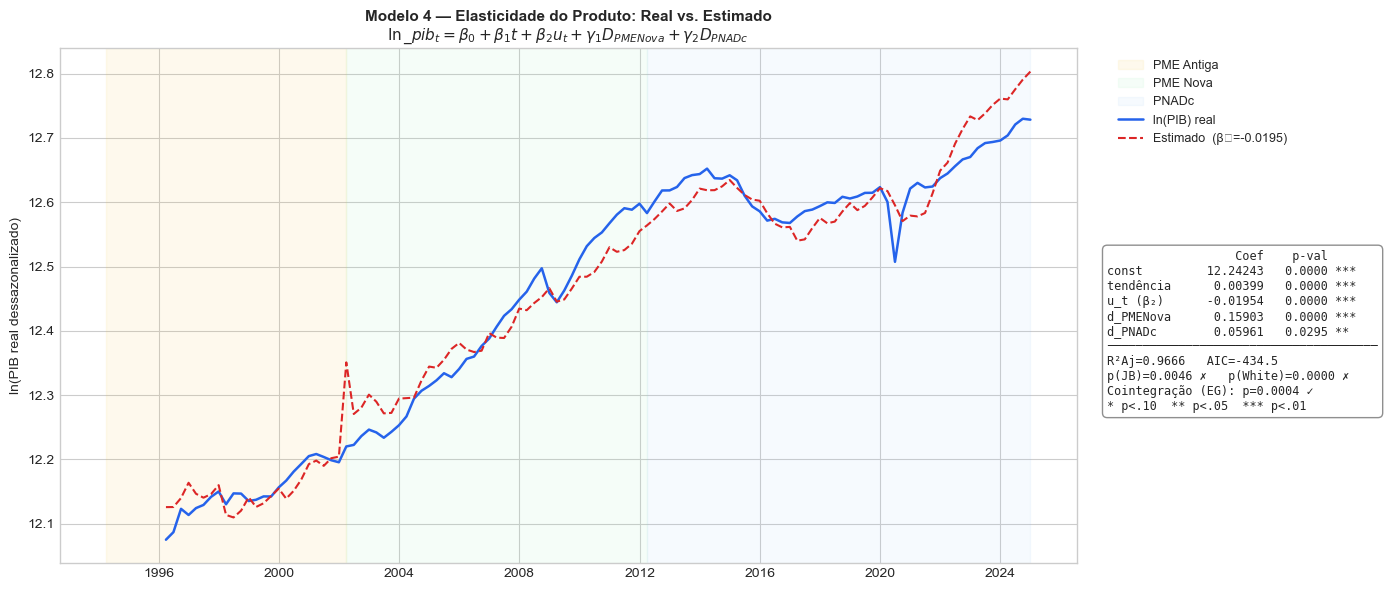

In [9]:
# ── FIGURA 18: ln_pib REAL vs. ESTIMADO ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
sombrear_periodos(ax)

ax.plot(df.index, df['ln_pib'], color=COR_PRINCIPAL, linewidth=1.8,
        label='ln(PIB) real')
ax.plot(df.index, modelo.fittedvalues, color=COR_FITTED, linewidth=1.5,
        linestyle='--', label=f'Estimado  (β₂={beta2:.4f})')

ax.set_ylabel('ln(PIB real dessazonalizado)', fontsize=10)
ax.set_title('Modelo 4 — Elasticidade do Produto: Real vs. Estimado\n'
             r'$\ln\_pib_t = \beta_0 + \beta_1 t + \beta_2 u_t + \gamma_1 D_{PMENova} + \gamma_2 D_{PNADc}$',
             fontsize=11, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.03, 1.0), fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))

_stars = lambda p: '***' if p < 0.01 else ('** ' if p < 0.05 else ('*  ' if p < 0.10 else '   '))
_lines = [f"{'':12}{'Coef':>10}  {'p-val':>7}"]
for _n in modelo.params.index:
    _lbl = {'const': 'const', 't': 'tendência', 'u_t': 'u_t (β₂)', 'd_PMENova': 'd_PMENova', 'd_PNADc': 'd_PNADc'}.get(_n, _n)
    _lines.append(f"{_lbl:<12}{modelo.params[_n]:>10.5f}  {modelo.pvalues[_n]:>7.4f} {_stars(modelo.pvalues[_n])}")
_lines += [
    '─' * 38,
    f"R²Aj={modelo.rsquared_adj:.4f}   AIC={modelo.aic:.1f}",
    f"p(JB)={jb_p:.4f} {'✓' if jb_p>0.05 else '✗'}   p(White)={wh_p:.4f} {'✓' if wh_p>0.05 else '✗'}",
    f"Cointegração (EG): p={pval_eg:.4f} {'✓' if pval_eg<0.05 else '✗'}",
    '* p<.10  ** p<.05  *** p<.01',
]
ax.annotate('\n'.join(_lines), xy=(1.03, 0.45), xycoords='axes fraction',
            va='center', ha='left', fontsize=8.5, family='monospace',
            annotation_clip=False,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.88))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_18_modelo_elasticidade.png', dpi=150, bbox_inches='tight')
print('fig_18 salva')
plt.show()

In [10]:
# ── DERIVAÇÃO DO PRODUTO POTENCIAL E HIATO IMPLÍCITO ─────────────────────────
# NAIRU por período: valores da Tabela 3.2.2 (Modelo 2 — Hamilton)
# PME Antiga (pré-2002):   6.63%
# PME Nova  (2002–2012):   9.91%
# PNADc     (pós-2012):    9.73%

nairu = pd.Series(np.nan, index=df.index)
nairu[df.index < '2002-03-31']  = 6.63
nairu[(df.index >= '2002-03-31') & (df.index < '2012-03-31')] = 9.91
nairu[df.index >= '2012-03-31'] = 9.73

# ln Y*_t = β₀ + β₁·t + β₂·NAIRU_t + γ₁·d_PMENova + γ₂·d_PNADc
ln_y_potencial = (beta0
                  + beta1 * df['t']
                  + beta2 * nairu
                  + gamma1 * df['d_PMENova']
                  + gamma2 * df['d_PNADc'])

df['ln_y_potencial'] = ln_y_potencial
df['hiato_elast']    = (df['ln_pib'] - ln_y_potencial) * 100

print('=== PRODUTO POTENCIAL IMPLÍCITO (Modelo 4 — Elasticidade) ===')
print(df[['ln_pib', 'ln_y_potencial', 'hiato_elast']].describe().round(4))
print(f"\nHiato: min={df['hiato_elast'].min():.2f}%  max={df['hiato_elast'].max():.2f}%  σ={df['hiato_elast'].std():.2f}%")

=== PRODUTO POTENCIAL IMPLÍCITO (Modelo 4 — Elasticidade) ===
         ln_pib  ln_y_potencial  hiato_elast
count  116.0000        116.0000     116.0000
mean    12.4498         12.4498      -0.0061
std      0.1992          0.1901       5.7153
min     12.0752         12.1169     -15.4455
25%     12.2427         12.3265      -3.2489
50%     12.5381         12.4412      -1.5274
75%     12.6157         12.6190       3.8670
max     12.7299         12.7336      13.5617

Hiato: min=-15.45%  max=13.56%  σ=5.72%


fig_19 salva


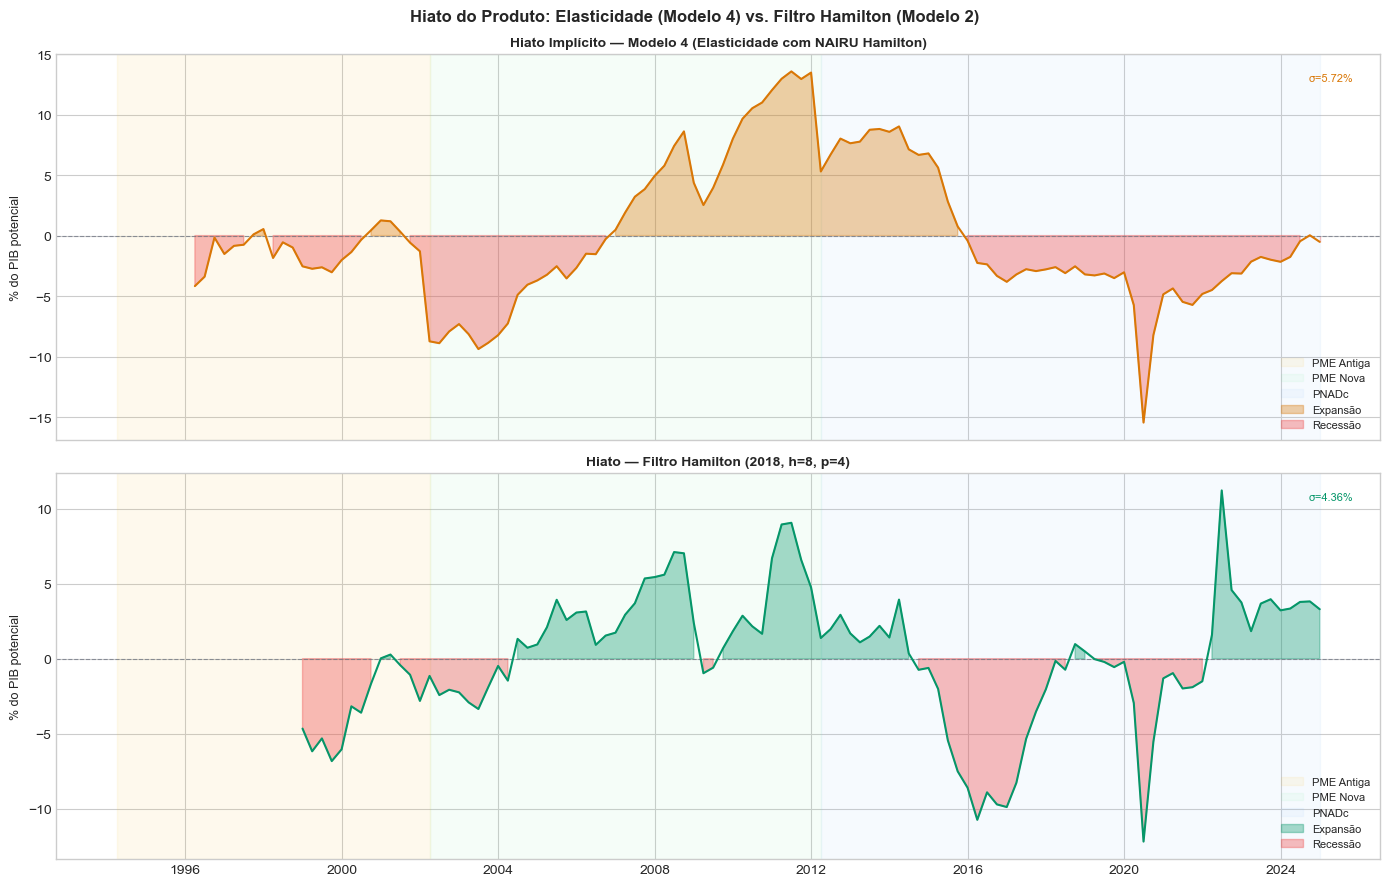

Correlação Hiato-Elast × Hiato-Hamilton: 0.523


In [11]:
# ── FIGURA 19: HIATO IMPLÍCITO (Elasticidade) vs. HIATO HAMILTON ─────────────
# Recarregar o hiato Hamilton do notebook 2 para comparação
pib_df2 = pd.read_pickle('../dados/pib_tratado.pkl')

def hamilton_filter(series, h=8, p=4):
    s = series.copy()
    X = pd.DataFrame({'const': 1.0}, index=s.index)
    for i in range(p):
        X[f'lag{h+i}'] = s.shift(h + i)
    valid = X.dropna().index
    modelo_ham = sm.OLS(s.loc[valid], X.loc[valid]).fit()
    fitted = pd.Series(np.nan, index=s.index)
    fitted.loc[valid] = modelo_ham.fittedvalues
    return (s - fitted) * 100, fitted

hiato_ham_serie, _ = hamilton_filter(pib_df2.loc['1996-01-01':'2024-12-31', 'ln_pib'])
hiato_ham_serie = hiato_ham_serie.dropna()

# ── Plot de comparação ────────────────────────────────────────────────────────
serie_elast = df['hiato_elast'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Hiato do Produto: Elasticidade (Modelo 4) vs. Filtro Hamilton (Modelo 2)',
             fontsize=12, fontweight='bold')

for ax, serie, cor, titulo, label in [
    (axes[0], serie_elast, COR_HIATO,
     'Hiato Implícito — Modelo 4 (Elasticidade com NAIRU Hamilton)',
     f'σ={serie_elast.std():.2f}%'),
    (axes[1], hiato_ham_serie, '#059669',
     'Hiato — Filtro Hamilton (2018, h=8, p=4)',
     f'σ={hiato_ham_serie.std():.2f}%'),
]:
    sombrear_periodos(ax)
    ax.axhline(0, color=COR_ZERO, linewidth=0.8, linestyle='--', alpha=0.7)
    ax.fill_between(serie.index, serie, 0,
                    where=(serie >= 0), alpha=0.35, color=cor, label='Expansão')
    ax.fill_between(serie.index, serie, 0,
                    where=(serie < 0),  alpha=0.35, color='#EF4444', label='Recessão')
    ax.plot(serie.index, serie, color=cor, linewidth=1.5)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_ylabel('% do PIB potencial', fontsize=9)
    ax.legend(fontsize=8, loc='lower right')
    ax.text(0.98, 0.95, label, transform=ax.transAxes,
            fontsize=8, color=cor, va='top', ha='right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_19_hiato_elasticidade_vs_hamilton.png', dpi=150, bbox_inches='tight')
print('fig_19 salva')
plt.show()

# Correlação entre os dois hiatos
idx_comum = serie_elast.index.intersection(hiato_ham_serie.index)
corr = np.corrcoef(serie_elast.loc[idx_comum], hiato_ham_serie.loc[idx_comum])[0, 1]
print(f'Correlação Hiato-Elast × Hiato-Hamilton: {corr:.3f}')

fig_20 salva


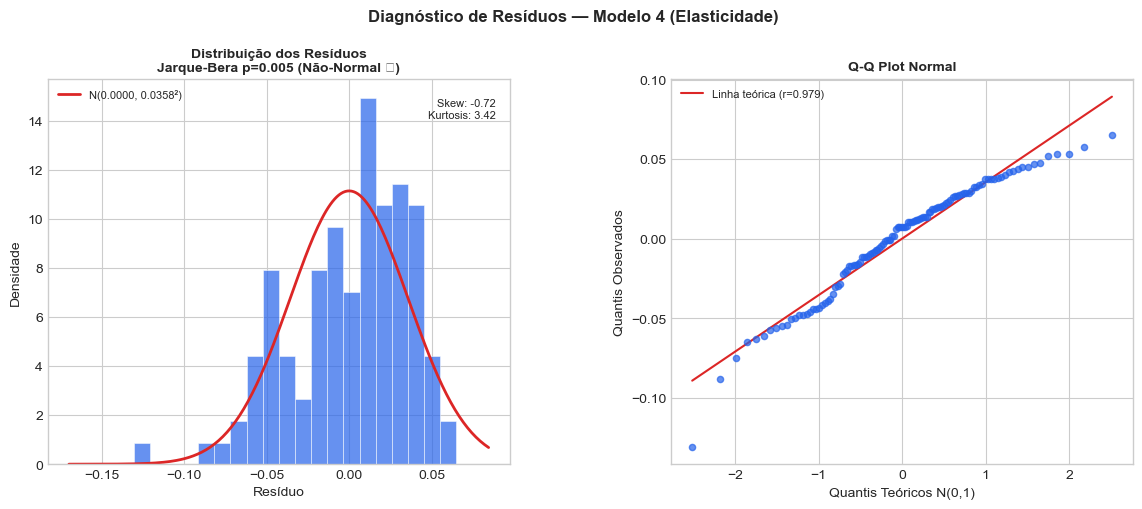

In [12]:
# ── FIGURA 20: DIAGNÓSTICO DE RESÍDUOS — Histograma + Q-Q ────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
xmin, xmax = residuos.min(), residuos.max()
x_vals = np.linspace(xmin * 1.3, xmax * 1.3, 200)
ax1.hist(residuos, bins=20, density=True, color=COR_PRINCIPAL, alpha=0.7,
         edgecolor='white', linewidth=0.5)
mu_r, sigma_r = residuos.mean(), residuos.std()
ax1.plot(x_vals, stats.norm.pdf(x_vals, mu_r, sigma_r),
         color=COR_FITTED, linewidth=2, label=f'N({mu_r:.4f}, {sigma_r:.4f}²)')
ax1.set_title(f'Distribuição dos Resíduos\nJarque-Bera p={jb_p:.3f} ({"Normal ✓" if jb_p>0.05 else "Não-Normal ✗"})',
              fontsize=10, fontweight='bold')
ax1.set_xlabel('Resíduo'); ax1.set_ylabel('Densidade')
ax1.legend(fontsize=8)
ax1.text(0.97, 0.95, f'Skew: {jb_sk:.2f}\nKurtosis: {jb_ku:.2f}',
         transform=ax1.transAxes, ha='right', va='top', fontsize=8)

ax2 = fig.add_subplot(gs[1])
(osm, osr), (slope, intercept, r_qq) = stats.probplot(residuos, dist='norm')
ax2.scatter(osm, osr, color=COR_PRINCIPAL, alpha=0.7, s=20, zorder=3)
x_line = np.array([min(osm), max(osm)])
ax2.plot(x_line, slope * x_line + intercept, color=COR_FITTED, linewidth=1.5,
         label=f'Linha teórica (r={r_qq:.3f})')
ax2.set_title('Q-Q Plot Normal', fontsize=10, fontweight='bold')
ax2.set_xlabel('Quantis Teóricos N(0,1)'); ax2.set_ylabel('Quantis Observados')
ax2.legend(fontsize=8)

fig.suptitle('Diagnóstico de Resíduos — Modelo 4 (Elasticidade)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_20_residuos_elasticidade.png', dpi=150, bbox_inches='tight')
print('fig_20 salva')
plt.show()

In [ ]:
# ── RESULTADO FINAL CONSOLIDADO ───────────────────────────────────────────────
print('\n' + '='*65)
print('MODELO 4 — ELASTICIDADE DO PRODUTO — RESULTADO FINAL')
print('='*65)
print(f'Equação: ln_pib_t = β₀ + β₁·t + β₂·u_t + γ₁·D_PMENova + γ₂·D_PNADc')
print(f'Amostra: {df.index[0].date()} → {df.index[-1].date()}  ({len(df)} obs)')
print()
print(f'  β₀ (intercepto):         {beta0:.4f}   (p={modelo.pvalues["const"]:.4f})')
print(f'  β₁ (tendência trim.):    {beta1:.6f}  (p={modelo.pvalues["t"]:.4f})')
print(f'     → crescimento anual potencial: {beta1*400:.3f}%')
print(f'  β₂ (elasticidade Okun):  {beta2:.4f}   (p={modelo.pvalues["u_t"]:.4f})')
print(f'  γ₁ (d_PMENova):          {gamma1:.4f}   (p={modelo.pvalues["d_PMENova"]:.4f})')
print(f'  γ₂ (d_PNADc):            {gamma2:.4f}   (p={modelo.pvalues["d_PNADc"]:.4f})')
print()
print(f'  R² Ajustado:  {modelo.rsquared_adj:.4f}')
print(f'  AIC:          {modelo.aic:.2f}')
print()
print(f'  Jarque-Bera:  p={jb_p:.4f}  {"✓ Normal" if jb_p>0.05 else "✗ Não-Normal"}')
print(f'  White:        p={wh_p:.4f}  {"✓ Homoced." if wh_p>0.05 else "✗ Heteroced. (HAC corrige)"}')
print(f'  Engle-Granger (ADF resíduos): p={pval_eg:.4f}  {"✓ Cointegração confirmada" if pval_eg<0.05 else "✗ Cointegração não confirmada"}')
print(f'  VIF máximo:   {vif_df["VIF"].max():.1f}  ← ver análise acima')
print()
print(f'  Hiato implícito: σ={df["hiato_elast"].std():.2f}%  '
      f'min={df["hiato_elast"].min():.2f}%  max={df["hiato_elast"].max():.2f}%')


MODELO 4 — ELASTICIDADE DO PRODUTO — RESULTADO FINAL
Equação: ln_pib_t = β₀ + β₁·t + β₂·u_t + γ₁·D_PMENova + γ₂·D_PNADc
Amostra: 1996-03-31 → 2024-12-31  (116 obs)

  β₀ (intercepto):         12.2424   (p=0.0000)
  β₁ (tendência trim.):    0.003988  (p=0.0000)
     → crescimento anual potencial: 1.595%
  β₂ (elasticidade Okun):  -0.0195   (p=0.0000)
  γ₁ (d_PMENova):          0.1590   (p=0.0000)
  γ₂ (d_PNADc):            0.0596   (p=0.0295)

  R² Ajustado:  0.9666
  AIC:          -434.52

  Jarque-Bera:  p=0.0046  ✗ Não-Normal
  White:        p=0.0000  ✗ Heteroced. (HAC corrige)
  Engle-Granger (ADF resíduos): p=0.0004  ✓ Cointegração confirmada
  VIF máximo:   17.2  ← ver análise acima

  Hiato implícito: σ=5.72%  min=-15.45%  max=13.56%


: 